In [ ]:
# 파이토치 환경 설정

In [1]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA 사용 가능:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.31  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Setup complete  (16 CPUs, 31.7 GB RAM, 170.1/475.9 GB disk)


In [4]:
import cv2
import ultralytics
import roboflow
import inference_sdk

In [5]:
print("OpenCV:", cv2.__version__)
print("ultralytics:", ultralytics.__version__)

OpenCV: 4.10.0
ultralytics: 8.4.31


In [ ]:
#로보플로 인퍼런스 api 사용하기

In [10]:
from inference_sdk import InferenceHTTPClient
#연결 클라이언트 생성
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="HYqU0MSpeDQFONy0ag88"
)

#추론 요청하기
result = CLIENT.infer('sample2.png', model_id="rock-paper-scissors-sxsw/14")
result

{'inference_id': '5704fa68-9428-4166-959d-d83cf2ad49e6',
 'time': 0.00863774516619742,
 'image': {'width': 580, 'height': 614},
 'predictions': [{'x': 129.5,
   'y': 120.5,
   'width': 257.0,
   'height': 99.0,
   'confidence': 0.8956668376922607,
   'class': 'Scissors',
   'class_id': 2,
   'detection_id': 'fa9dd3e6-12dd-4e70-80c3-e5d0db09ab50'},
  {'x': 128.5,
   'y': 503.5,
   'width': 255.0,
   'height': 111.0,
   'confidence': 0.7342231273651123,
   'class': 'Paper',
   'class_id': 0,
   'detection_id': 'db25e10b-eb06-4abe-afe7-fff6d2c00fc4'},
  {'x': 117.0,
   'y': 315.5,
   'width': 230.0,
   'height': 123.0,
   'confidence': 0.7297146916389465,
   'class': 'Paper',
   'class_id': 0,
   'detection_id': 'a1e97f8a-3b0f-4643-a19a-17357391fde0'}]}

In [ ]:
#gpu 확인

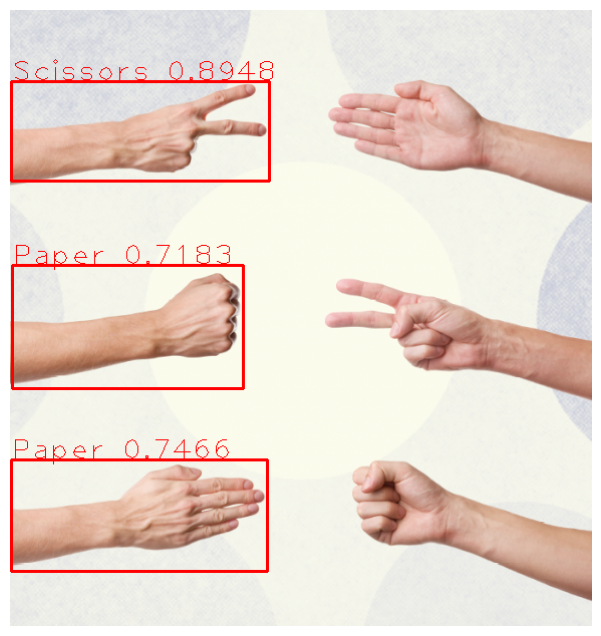

In [11]:
import cv2
import matplotlib.pyplot as plt

filename = 'sample2.png'
result = CLIENT.infer(filename, model_id="rock-paper-scissors-sxsw/14")
img = cv2.imread(filename)

for pred in result["predictions"]:
    x, y = pred['x'], pred['y']
    width, height = pred['width'], pred['height']
    conf = pred['confidence']
    cls = pred['class']
    x1, y1 = int(x-width/2), int(y-height/2)
    x2, y2 = int(x+width/2), int(y+height/2)
    cv2.rectangle(img, (x1,y1), (x2, y2), (0,0,255), 2)
    cv2.putText(img, f'{cls} {conf:.4f}', (x1,y1), cv2.FONT_HERSHEY_PLAIN, 2, (0,0,255))

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()